# Inference MicNet model


In [18]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys

import skimage
import skimage.io
import tifffile

import time
import torch
import torch.hub
import torch.nn

from alias_multinomial import AliasMethod
from utils_eval import NCESoftmaxLoss, NCECriterion
from MicNet_model import *

## 1) Load data

(41048, 30035, 3)


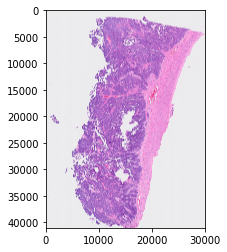

In [6]:
image_file = "./Sample_data/Dataset_HOC/5_CytAssist_11mm_FFPE_Human_Ovarian_Carcinoma_tissue_image.tif"

image = tifffile.imread(image_file)
print(image.shape)
image_norm = image.copy()
plt.imshow(image)
plt.show()

In [7]:
count_stat = pd.read_csv("./output/Dataset_HOC/1_count_stat_ovarian.csv", index_col=0)
count = pd.read_csv("./output/Dataset_HOC/1_pd_count_norm_ovarian.csv", index_col=0)

In [8]:
pd_meta = pd.read_csv('./Sample_data/Dataset_HOC/meta_df.csv', index_col=0)

pd_meta = pd_meta[['pxl_row_in_fullres', 'pxl_col_in_fullres']].copy()
pd_meta.columns = ['X', 'Y']


In [9]:
# Split training and testing
np.random.seed(82321)
indexes_all = pd_meta.index.values
training_indexes = np.random.choice(indexes_all, int(len(indexes_all) * 0.8), replace=False)
testing_indexes = [_ for _ in indexes_all if _ not in training_indexes]
print("#Training: {}, #Testing: {}".format(len(training_indexes), len(testing_indexes)))
training_indexes.sort()
testing_indexes.sort()

#Training: 3739, #Testing: 935


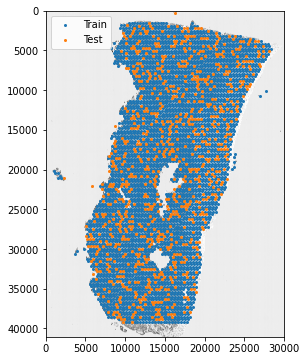

In [10]:
# Plot training & testing distribution
plt.figure(figsize=(6, 6))
plt.imshow(image_norm[..., 0], cmap="gray")
coords_x = pd_meta.loc[training_indexes, "Y"].values
coords_y = pd_meta.loc[training_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Train")
coords_x = pd_meta.loc[testing_indexes, "Y"].values
coords_y = pd_meta.loc[testing_indexes, "X"].values
plt.scatter(coords_x, coords_y, s=4, label="Test")
plt.gca().set_aspect('equal')
plt.xlim(0, image.shape[1])
plt.ylim(image.shape[0], 0)
plt.legend()
plt.show()

In [11]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max
count_max = np.log2(count_stat.loc['max', :].values + 1)
count_max[count_max < 1] = 1
count = count/count_max

In [12]:
count

,EMC10,ARHGEF28,NUDT2,ITPR3,TMEM151B,CSKMT,DYNLL1,CENPQ,MSH6,HTR2B,...,CYTH4,SNAPC3,TYMP,CPTP,WBP2,OR7C2,SV2B,HSPA14,TBCE,TMSB15B
AACAATGTGCTCCGAG-1,0.577714,0.000000,0.000000,0.709529,0.000000,0.556307,0.000000,0.598244,0.726870,0.000000,...,0.000000,0.517354,0.000000,0.709155,0.582289,0.000000,0.0,0.720520,0.700419,0.603897
AACACCATTCGCATAC-1,0.518919,0.000000,0.640593,0.747078,0.000000,0.000000,0.000000,0.638735,0.662558,0.000000,...,0.000000,0.552371,0.671911,0.582444,0.000000,0.000000,0.0,0.607465,0.000000,0.000000
AACACGTTGATACCGC-1,0.699717,0.000000,0.545101,0.735134,0.000000,0.505420,0.687527,0.543520,0.736323,0.000000,...,0.514083,0.624173,0.404326,0.762166,0.445062,0.000000,0.0,0.713477,0.685950,0.000000
AACACTCGTGAGCTTC-1,0.732488,0.465871,0.527088,0.718204,0.000000,0.000000,0.628785,0.637155,0.761786,0.467891,...,0.000000,0.454497,0.585601,0.581003,0.430354,0.543997,0.0,0.698443,0.769393,0.000000
AACAGCCTCCTGACTA-1,0.678643,0.616983,0.631762,0.830263,0.000000,0.647240,0.622278,0.629930,0.613170,0.560809,...,0.595812,0.741456,0.385706,0.634691,0.424566,0.000000,0.0,0.600274,0.666578,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTTGCTATCGGTGGC-1,0.740215,0.505666,0.000000,0.623040,0.000000,0.000000,0.610533,0.000000,0.601598,0.000000,...,0.000000,0.648020,0.642411,0.810693,0.467115,0.000000,0.0,0.697503,0.729185,0.579940
TGTTGGCCTGTAGCGG-1,0.690938,0.453720,0.513339,0.775930,0.000000,0.475970,0.616158,0.000000,0.766365,0.455686,...,0.000000,0.694437,0.380767,0.732245,0.510256,0.000000,0.0,0.648594,0.598563,0.000000
TGTTGGTGCGCACGAG-1,0.663483,0.000000,0.000000,0.641153,0.000000,0.653485,0.628282,0.000000,0.719454,0.000000,...,0.664686,0.000000,0.522775,0.744705,0.000000,0.000000,0.0,0.659631,0.000000,0.000000
TGTTGGTGCGGAATCA-1,0.599781,0.554076,0.626882,0.757610,0.547061,0.000000,0.558831,0.513733,0.682690,0.556477,...,0.000000,0.718113,0.464987,0.734030,0.420671,0.000000,0.0,0.688510,0.720861,0.000000


In [13]:
PATCH_SIZE = 256

## 2) Check data loader

In [14]:
# from utils_data import Dataset
from utils_data import normalize, augmentor

import numpy as np
import math
import skimage
import skimage.transform

import torch
import torch.utils
import torch.utils.data
    
# Get image patch
def get_image_patch(image, coords, patch_size):
    """
    Args:
        coords: center of image; x, y (col, row) in pixels
    """
    row_start = int(coords[1] - patch_size/2)
    col_start = int(coords[0] - patch_size/2)
    return image[row_start:row_start + patch_size, col_start:col_start + patch_size]

class Dataset(torch.utils.data.Dataset):
    __initialized = False
    def __init__(self, indexes, image, count_df, meta_df, augmentation=False):
        """
        Args:
            indexes: index used for both count_df and meta_df
        """
        self.indexes = indexes
        self.image = image
        self.count_df = count_df
        self.meta_df = meta_df
        self.augmentation = augmentation
        self.__initialized = True

    def __len__(self):
        """Denotes the number of samples"""
        return len(self.indexes)
    
    def __getitem__(self, index):
        """Generate one batch of data.
        
        Returns:
            index: indexes of samples (long)
        """
        # Generate data
        data = self.__data_generation(self.indexes[index])

        return data, index
    
    def __data_generation(self, indexes):
        """Generates data containing batch_size samples.
        
        Returns:
            data: a dictionary with data.image in [b, ch, h, w]; data.gene in [b, n_genes]
        """
        image = get_image_patch(self.image, 
                                [self.meta_df.loc[indexes, "Y"], self.meta_df.loc[indexes, "X"]], 
                                PATCH_SIZE)  # meta_df mistakes X/Y
        if self.augmentation:
            image = augmentor(normalize(image))
        else:
            image = normalize(image)
        
        data = dict()
        data['image'] = torch.tensor(np.transpose(image, (2, 0, 1)).astype(float))
        data['gene'] = torch.tensor(self.count_df.loc[indexes, :].values)
        
        return data 

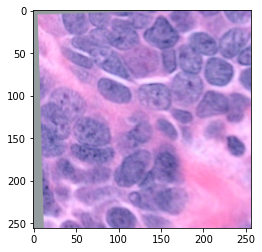

tensor([2518])


In [15]:
# Generator
np.random.seed()
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)
for x, y in train_loader:
    plt.imshow(normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True))
    plt.show()
    print(y)
    break

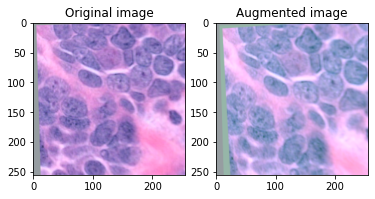

In [16]:
image = normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True)
plt.subplot(121)
plt.imshow(image)
plt.title("Original image")
plt.subplot(122)
plt.imshow(normalize(augmentor(normalize(image)), inverse=True))
plt.title("Augmented image")
plt.show()

## 3) Create network

In [19]:
from torch.nn.modules import MSELoss

device = torch.device("cuda:2")
image_shape = PATCH_SIZE
n_genes = count_stat.shape[1]
n_data = len(training_indexes)
n_out_features = 100
imagenet = 'resnet101'

# NCE parameters
nce_k = 100
nce_t = 0.07
nce_m = 0.9
softmax = False

# Training parameters
lr = 0.01   
momentum = 0.9
weight_decay = 0.0001
gradient_clip = 5

# Generator
train_set = Dataset(training_indexes, image_norm, count, pd_meta, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=20, shuffle=True, num_workers=1)
test_set = Dataset(testing_indexes, image_norm, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

# Set model
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, 
               imagenet=imagenet, genenet=[500, 100]).to(device)
contrast = NCEAverage(n_out_features, n_data, nce_k, nce_t, nce_m, softmax, device=device).to(device)
criterion_image = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_gene = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_rec = MSELoss().to(device)

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(),
                            lr=lr,
                            momentum=momentum,
                            weight_decay=weight_decay)

In [20]:
model_dir = "./models/Dataset_HOC"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

In [21]:
model

MicNet(
  (imagenet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          

In [22]:
"""TO LOAD:"""
model_file = os.path.join(model_dir, "epoch_best.pt")
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

=> loading checkpoint './models/Dataset_HOC/epoch_best.pt'


## 4) Validate and save result

In [21]:
test_set = Dataset(indexes_all, image_norm, count, pd_meta, augmentation=False)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=20, shuffle=False, num_workers=1)

In [22]:
model.eval()

with torch.no_grad():
    for idx, (data, index) in enumerate(test_loader):
        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        
        # Append
        if idx == 0:
            feat_images = feat_image.cpu().numpy()
            feat_genes = feat_gene.cpu().numpy()
        else:
            feat_images = np.concatenate([feat_images, feat_image.cpu().numpy()])
            feat_genes = np.concatenate([feat_genes, feat_gene.cpu().numpy()])

In [23]:
feat_images.shape

(4674, 100)

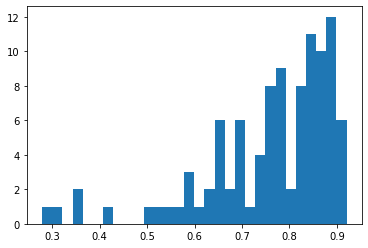

In [24]:
# Normalize & calculate correlation
from scipy.stats import spearmanr

feat_images = feat_images / np.sum(feat_images ** 2, axis=1, keepdims=True) ** 0.5
feat_genes = feat_genes / np.sum(feat_genes ** 2, axis=1, keepdims=True) ** 0.5
corr = []
for i in range(feat_images.shape[1]):
    corr.append(spearmanr(feat_images[:, i], feat_genes[:, i]).correlation)
plt.hist(corr, bins=30)
plt.show()

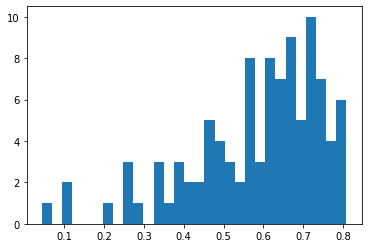

In [25]:
# Normalize & calculate correlation in testing set
from scipy.stats import spearmanr

_feat_images = np.array([feat_images[_, :] for _, index in enumerate(indexes_all) if index in testing_indexes])
_feat_genes = np.array([feat_genes[_, :] for _, index in enumerate(indexes_all) if index in testing_indexes])
corr = []
for i in range(_feat_images.shape[1]):
    corr.append(spearmanr(_feat_images[:, i], _feat_genes[:, i]).correlation)
plt.hist(corr, bins=30)
plt.show()

In [28]:
# Save result
torch.save([feat_images, feat_genes], "./output/Dataset_HOC/3_IGC_ovarian_all_indexes_features.pt")

# 4) Clustering

In [23]:
feat_images, feat_genes = torch.load("./output/Dataset_HOC/3_IGC_ovarian_all_indexes_features.pt")

image_feature = feat_images
gene_feature = feat_genes

In [25]:
### Read Ground Truth

GT_file='./Sample_data/Dataset_HOC/Ground_truth_3cluster.csv'
GT_raw= pd.read_csv(GT_file,index_col=0)
GT_raw

,annotation
barcode,
AACAATGTGCTCCGAG-1,tumor
AACACCATTCGCATAC-1,Surrounding tumor
AACACGTTGATACCGC-1,non-tumor
AACACTCGTGAGCTTC-1,tumor
AACAGCCTCCTGACTA-1,Surrounding tumor
...,...
TGTTGCTATCGGTGGC-1,Surrounding tumor
TGTTGGCCTGTAGCGG-1,tumor
TGTTGGTGCGCACGAG-1,tumor


In [26]:
import numpy as np
import pandas as pd

# Concatenate features
MicNet_embedding_array = np.concatenate((image_feature, gene_feature), axis=1)

# Convert to DataFrame and add GT_raw index
MicNet_embedding = pd.DataFrame(MicNet_embedding_array, index=GT_raw.index)

In [27]:
import numpy as np
import pandas as pd

def run_clustering(method, embedding, index=None, label_name="label", fill_value=-1):
    """
    Run clustering with NaN-safe masking and return a DataFrame with cluster labels.

    Parameters
    ----------
    method : Kmeans or SpectralClustering
    embedding : np.ndarray or pd.DataFrame
        2D array of shape (n_samples, n_features). May contain NaNs.
    index : pd.Index or list-like, optional
        Index to assign to the returned DataFrame. If None, defaults to 0..n-1.
    label_name : str, optional
        Column name for cluster labels in the returned DataFrame.
    fill_value : int, optional
        Value to assign for rows with NaN embeddings (default=-1).

    Returns
    -------
    df : pd.DataFrame
        DataFrame with one column containing cluster labels as integers.
        Invalid rows get `fill_value`. Index matches `index` if provided.
    """
    # Mask for valid samples (no NaNs across features)
    mask_valid = ~np.any(np.isnan(embedding), axis=1)

    # Allocate integer array with fill_value
    Y = np.full(embedding.shape[0], fill_value, dtype=int)

    # Fit method only on valid rows
    Cluster = method.fit(embedding[mask_valid])

    # Assign cluster labels back
    Y[mask_valid] = Cluster.labels_.astype(int)

    # Return DataFrame with correct index
    if index is None:
        index = range(embedding.shape[0])
    return pd.DataFrame({label_name: Y}, index=index)


In [29]:
from sklearn.cluster import KMeans

n_clusters = 3
method = KMeans(init='k-means++', n_clusters=n_clusters, n_init=50, max_iter=500, random_state=0)
MicNet_df       = run_clustering(method, MicNet_embedding.to_numpy(), MicNet_embedding.index, "label")

In [30]:
MicNet_df      = MicNet_df.reindex(GT_raw.index)
import numpy as np
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Ground truth
gt = GT_raw['annotation']

# Dictionary of prediction dataframes
pred_dfs = {
    "MicNet": MicNet_df,
}

# Store results
scores = {}

for name, df in pred_dfs.items():
    # pick the right label column
    if "label" in df.columns:
        Y = df['label'].to_numpy()
    elif "cluster" in df.columns:
        Y = df['cluster'].to_numpy()
    else:
        raise ValueError(f"{name} dataframe missing label column")

    # Masks: keep only samples with both predictions and GT
    mask_pred = ~np.isnan(Y)
    mask_gt   = gt.notna().to_numpy()
    mask_common = mask_pred & mask_gt

    y_true = gt.to_numpy()[mask_common]
    y_pred = Y[mask_common].astype(int)

    # Compute ARI and AMI
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)

    scores[name] = {"ARI": ari, "AMI": ami, "n_samples": mask_common.sum()}

# Print results
for name, score in scores.items():
    print(f"{name}: ARI={score['ARI']:.4f}, AMI={score['AMI']:.4f} (n={score['n_samples']})")


MicNet: ARI=0.4944, AMI=0.5173 (n=4674)


# Session Info

In [33]:
!pip freeze

absl-py==0.7.0
adjustText==0.7.3
altair==3.2.0
anndata==0.7.5
argh==0.26.2
ase==3.21.1
astor==0.7.1
astropy==3.2.1
atomicwrites==1.3.0
attrs==19.1.0
autograd==1.3
autograd-gamma==0.5.0
backcall==0.1.0
base58==1.0.3
bleach==1.5.0
blinker==1.4
boto3==1.10.15
botocore==1.13.15
Bottleneck==1.2.1
cachetools==4.1.0
certifi==2021.5.30
chardet==3.0.4
charset-normalizer==2.0.4
Click==7.0
cvxopt==1.2.3
cvxpy==1.0.24
cycler==0.10.0
Cython==0.29.15
dataclasses==0.8
decorator==4.4.0
defusedxml==0.5.0
dill==0.2.9
docutils==0.15.2
ecos==2.0.7.post1
entrypoints==0.3
enum-compat==0.0.3
environment-kernels==1.1.1
fastcluster==1.2.4
FITS-tools==0.2
formulaic==0.2.4
future==0.17.1
gast==0.2.2
get-version==2.1
google-auth==1.14.3
google-auth-oauthlib==0.4.1
google-pasta==0.2.0
googledrivedownloader==0.4
grpcio==1.29.0
h5py==2.10.0
html5lib==0.9999999
idna==3.2
image-registration==0.2.4
imagecodecs==2020.5.30
imagecodecs-lite==2020.1.31
imageio==2.6.1
importlib-metadata==0.23
interface-meta==1.2.3
ipykernel